# 🛒 Supermarket Sales Analysis

**Student Name:** *(Enter your name here)*  
**Course:** BCA / B.Sc Data Analytics  
**Institution:** *(Enter your institution name here)*  
**Year:** 2026

---

## Problem Statement

Supermarkets generate large volumes of transactional data daily. Without proper analysis, this data cannot be used effectively. This project uses Exploratory Data Analysis (EDA) to analyze 500 supermarket sales transactions and extract useful business insights.

---

## Project Objectives

1. Load and understand the supermarket sales dataset.
2. Perform data quality checks and clean the data.
3. Verify sales calculations.
4. Analyze products, categories, branches, cities, customer types, and payment methods.
5. Study customer ratings and time-based sales trends.
6. Answer key business questions using calculated data.
7. Visualize findings using charts.
8. Provide business recommendations based on actual findings.

---

## Dataset Information

- **Source:** [Google Sheets Dataset](https://docs.google.com/spreadsheets/d/1QIX__4VObHFMEXnRM2xJyXmB5JAB2peHrJcQ41_U9TE/edit?usp=sharing)
- **File:** `data/supermarket_sales.csv`
- **Rows:** 500 transactions
- **Columns:** 13
- **Period:** January 2026 – July 2026
- **Branches:** A (Jaipur), B (Delhi), C (Mumbai), D (Bengaluru)

---
## 1. Import Libraries

In [1]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

# Suppress unnecessary warnings
warnings.filterwarnings('ignore')

# Set chart style for clean-looking plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

print('All libraries imported successfully.')

All libraries imported successfully.


---
## 2. Data Loading

In [2]:
# Load the dataset from the data folder
df = pd.read_csv('data/supermarket_sales.csv')

print('Dataset loaded successfully.')
print(f'Shape: {df.shape[0]} rows × {df.shape[1]} columns')

Dataset loaded successfully.
Shape: 500 rows × 13 columns


In [3]:
# Display the first 5 rows
print('--- First 5 Rows ---')
df.head()

--- First 5 Rows ---


,Invoice ID,Date,Branch,City,Customer Type,Gender,Product,Category,Quantity,Unit Price,Payment,Rating,Sales
0,INV0001,2026-06-01,A,Jaipur,Member,Male,Milk,Dairy,4,57.13,UPI,3.8,228.52
1,INV0002,2026-02-26,A,Jaipur,Normal,Male,Rice,Grocery,9,66.85,Net Banking,3.9,601.65
2,INV0003,2026-02-09,C,Mumbai,Normal,Female,Milk,Dairy,3,57.28,Card,3.4,171.84
3,INV0004,2026-01-12,C,Mumbai,Member,Female,Shampoo,Personal Care,2,168.27,Card,4.5,336.54
4,INV0005,2026-06-30,A,Jaipur,Normal,Female,Apples,Fruits,5,130.57,Cash,3.1,652.85


In [4]:
# Display the last 5 rows
print('--- Last 5 Rows ---')
df.tail()

--- Last 5 Rows ---


,Invoice ID,Date,Branch,City,Customer Type,Gender,Product,Category,Quantity,Unit Price,Payment,Rating,Sales
495,INV0496,2026-01-30,B,Delhi,Normal,Male,Tea,Beverages,8,128.86,Net Banking,3.5,1030.88
496,INV0497,2026-05-13,D,Bengaluru,Normal,Female,Eggs,Dairy,4,92.55,Card,4.1,370.20
497,INV0498,2026-05-22,C,Mumbai,Normal,Female,Eggs,Dairy,7,86.94,UPI,4.9,608.58
498,INV0499,2026-02-21,D,Bengaluru,Member,Male,Tea,Beverages,10,117.19,Net Banking,3.5,1171.90
499,INV0500,2026-01-28,B,Delhi,Normal,Female,Face Wash,Personal Care,4,114.37,Cash,3.2,457.48


In [5]:
# Display column names
print('Column Names:')
print(df.columns.tolist())

Column Names:
['Invoice ID', 'Date', 'Branch', 'City', 'Customer Type', 'Gender', 'Product', 'Category', 'Quantity', 'Unit Price', 'Payment', 'Rating', 'Sales']


In [6]:
# Display data types
print('Data Types:')
print(df.dtypes)

Data Types:
Invoice ID           str
Date                 str
Branch               str
City                 str
Customer Type        str
Gender               str
Product              str
Category             str
Quantity           int64
Unit Price       float64
Payment              str
Rating           float64
Sales            float64
dtype: object


---
## 3. Data Quality Check

In this section, we check:
- Missing values
- Duplicate rows
- Data types
- Value ranges for Quantity, Unit Price, and Rating
- Basic statistical summary

In [7]:
# ---- Missing Value Check ----
print('Missing Values per Column:')
print(df.isnull().sum())
print(f'\nTotal missing values: {df.isnull().sum().sum()}')

Missing Values per Column:
Invoice ID       0
Date             0
Branch           0
City             0
Customer Type    0
Gender           0
Product          0
Category         0
Quantity         0
Unit Price       0
Payment          0
Rating           0
Sales            0
dtype: int64

Total missing values: 0


In [8]:
# ---- Duplicate Row Check ----
duplicates = df.duplicated().sum()
print(f'Duplicate rows: {duplicates}')

Duplicate rows: 0


In [9]:
# ---- Check Quantity and Unit Price ----
print(f'Quantity  → min: {df["Quantity"].min()}, max: {df["Quantity"].max()}')
print(f'Unit Price → min: {df["Unit Price"].min()}, max: {df["Unit Price"].max()}')

# Check for any zero or negative values (invalid)
invalid_qty = df[df['Quantity'] <= 0].shape[0]
invalid_price = df[df['Unit Price'] <= 0].shape[0]
print(f'Invalid Quantity (<=0): {invalid_qty}')
print(f'Invalid Unit Price (<=0): {invalid_price}')

Quantity  → min: 1, max: 10
Unit Price → min: 27.67, max: 236.71
Invalid Quantity (<=0): 0
Invalid Unit Price (<=0): 0


In [10]:
# ---- Rating Range Check ----
print(f'Rating → min: {df["Rating"].min()}, max: {df["Rating"].max()}, avg: {df["Rating"].mean():.2f}')

# Check for ratings outside the expected range (1 to 5)
invalid_rating = df[(df['Rating'] < 1) | (df['Rating'] > 5)].shape[0]
print(f'Invalid Ratings (outside 1–5): {invalid_rating}')

Rating → min: 3.0, max: 5.0, avg: 3.99
Invalid Ratings (outside 1–5): 0


In [11]:
# ---- Basic Statistical Summary ----
df.describe()

,Quantity,Unit Price,Rating,Sales
count,500.000000,500.000000,500.000000,500.000000
mean,5.536000,88.660700,3.994400,488.822160
std,2.875629,57.284029,0.574481,437.327833
min,1.000000,27.670000,3.000000,28.610000
25%,3.000000,43.955000,3.500000,189.212500
50%,5.500000,61.880000,4.000000,335.910000
75%,8.000000,128.567500,4.500000,609.885000
max,10.000000,236.710000,5.000000,2114.820000


### Data Quality Findings

- **Missing values:** None — the dataset is complete.
- **Duplicate rows:** None found.
- **Quantity:** All values are positive and valid.
- **Unit Price:** All values are positive and valid.
- **Rating:** All ratings fall within the 3.0–5.0 range — no invalid entries.
- **Data types:** The `Date` column is currently stored as a string. We will convert it to a proper datetime type in the cleaning step.

---
## 4. Data Cleaning

In [12]:
# Convert the Date column to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Extract useful time-based columns for later analysis
df['Month'] = df['Date'].dt.to_period('M')          # e.g. 2026-01
df['Month_Name'] = df['Date'].dt.strftime('%b %Y')  # e.g. Jan 2026
df['Day_of_Week'] = df['Date'].dt.day_name()        # e.g. Monday

print('Date column converted. New time columns added.')
print(df[['Date', 'Month', 'Month_Name', 'Day_of_Week']].head())

Date column converted. New time columns added.
        Date    Month Month_Name Day_of_Week
0 2026-06-01  2026-06   Jun 2026      Monday
1 2026-02-26  2026-02   Feb 2026    Thursday
2 2026-02-09  2026-02   Feb 2026      Monday
3 2026-01-12  2026-01   Jan 2026      Monday
4 2026-06-30  2026-06   Jun 2026     Tuesday


In [13]:
# Confirm final shape after cleaning
print(f'Final dataset shape: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'All columns: {df.columns.tolist()}')

Final dataset shape: 500 rows × 16 columns
All columns: ['Invoice ID', 'Date', 'Branch', 'City', 'Customer Type', 'Gender', 'Product', 'Category', 'Quantity', 'Unit Price', 'Payment', 'Rating', 'Sales', 'Month', 'Month_Name', 'Day_of_Week']


### Cleaning Summary

- No rows were removed — the dataset was already clean.
- `Date` was converted from string to datetime.
- Three new columns were added: `Month`, `Month_Name`, `Day_of_Week` — these will be used in the time analysis section.

---
## 5. Sales Calculation

We verify the `Sales` column by checking whether `Sales == Quantity × Unit Price`.

In [14]:
# Calculate sales independently from Quantity and Unit Price
df['Calculated_Sales'] = df['Quantity'] * df['Unit Price']

# Round both columns to 2 decimal places to avoid floating-point issues
df['Calculated_Sales'] = df['Calculated_Sales'].round(2)
df['Sales'] = df['Sales'].round(2)

# Compare: find rows where they differ
mismatches = df[df['Sales'] != df['Calculated_Sales']].shape[0]
print(f'Mismatches between Sales and Calculated_Sales: {mismatches}')

# Show sample comparison
df[['Invoice ID', 'Quantity', 'Unit Price', 'Calculated_Sales', 'Sales']].head()

Mismatches between Sales and Calculated_Sales: 0


,Invoice ID,Quantity,Unit Price,Calculated_Sales,Sales
0,INV0001,4,57.13,228.52,228.52
1,INV0002,9,66.85,601.65,601.65
2,INV0003,3,57.28,171.84,171.84
3,INV0004,2,168.27,336.54,336.54
4,INV0005,5,130.57,652.85,652.85


**Finding:** `Sales` exactly equals `Quantity × Unit Price` for all 500 rows. The `Sales` column is accurate. We will continue using `Sales` as our primary revenue metric.

---
## 6. Exploratory Data Analysis (EDA)

### 6A. Product Analysis

In [15]:
# Total sales, quantity, and transaction count by product
product_analysis = df.groupby('Product').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Quantity=('Quantity', 'sum'),
    Transaction_Count=('Invoice ID', 'count')
).sort_values('Total_Sales', ascending=False).round(2)

print('Product Analysis (sorted by Total Sales):')
product_analysis

Product Analysis (sorted by Total Sales):


,Total_Sales,Total_Quantity,Transaction_Count
Product,,,
Cheese,27906.30,126,26
Coffee,27694.87,153,24
Shampoo,27497.48,152,27
Cooking Oil,21525.06,142,26
Tea,17681.59,146,29
Apples,17057.41,119,20
Face Wash,11946.85,100,19
Rice,11754.17,167,29
Cold Drink,10731.78,166,29


In [16]:
# Highest and lowest selling product
best_product = product_analysis['Total_Sales'].idxmax()
worst_product = product_analysis['Total_Sales'].idxmin()

print(f'Best-selling product : {best_product}  → ₹{product_analysis.loc[best_product, "Total_Sales"]:,.2f}')
print(f'Lowest-selling product: {worst_product} → ₹{product_analysis.loc[worst_product, "Total_Sales"]:,.2f}')

Best-selling product : Cheese  → ₹27,906.30
Lowest-selling product: Biscuits → ₹3,908.87


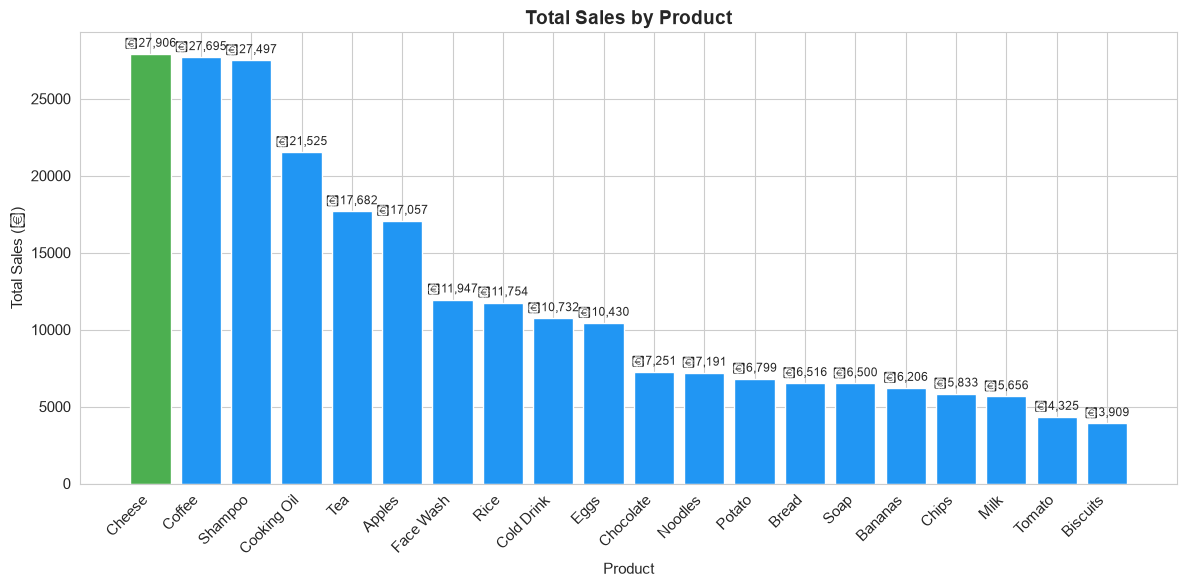

In [17]:
# Chart: Total Sales by Product
fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#2196F3' if p != best_product else '#4CAF50' for p in product_analysis.index]
bars = ax.bar(product_analysis.index, product_analysis['Total_Sales'], color=colors, edgecolor='white')

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 300,
            f'₹{height:,.0f}', ha='center', va='bottom', fontsize=8.5)

ax.set_title('Total Sales by Product', fontsize=14, fontweight='bold')
ax.set_xlabel('Product')
ax.set_ylabel('Total Sales (₹)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('chart_product_sales.png', dpi=150, bbox_inches='tight')
plt.show()

### 6B. Category Analysis

In [18]:
# Total sales, quantity, and transaction count by category
category_analysis = df.groupby('Category').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Quantity=('Quantity', 'sum'),
    Transaction_Count=('Invoice ID', 'count')
).sort_values('Total_Sales', ascending=False).round(2)

print('Category Analysis:')
category_analysis

Category Analysis:


,Total_Sales,Total_Quantity,Transaction_Count
Category,,,
Beverages,56108.24,465,82
Personal Care,45943.96,399,73
Dairy,43992.00,345,68
Grocery,40470.47,439,82
Fruits,23263.17,223,44
Snacks,16992.97,443,75
Vegetables,11124.17,290,48
Bakery,6516.10,164,28


In [19]:
best_category = category_analysis['Total_Sales'].idxmax()
most_qty_category = category_analysis['Total_Quantity'].idxmax()

print(f'Highest-selling category : {best_category}  → ₹{category_analysis.loc[best_category, "Total_Sales"]:,.2f}')
print(f'Most quantity sold category: {most_qty_category} → {category_analysis.loc[most_qty_category, "Total_Quantity"]} units')

Highest-selling category : Beverages  → ₹56,108.24
Most quantity sold category: Beverages → 465 units


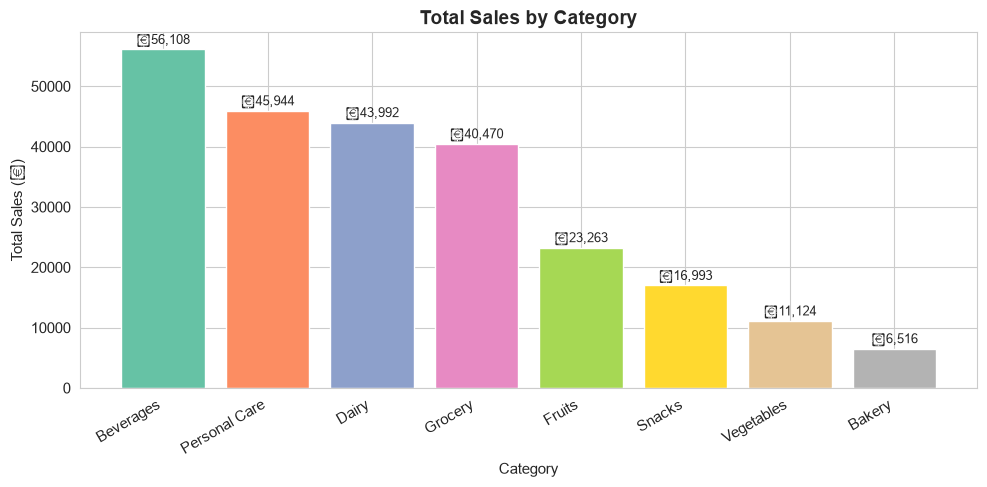

In [20]:
# Chart: Total Sales by Category
fig, ax = plt.subplots(figsize=(10, 5))
palette = sns.color_palette('Set2', len(category_analysis))
bars = ax.bar(category_analysis.index, category_analysis['Total_Sales'],
              color=palette, edgecolor='white')

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 400,
            f'₹{height:,.0f}', ha='center', va='bottom', fontsize=9)

ax.set_title('Total Sales by Category', fontsize=14, fontweight='bold')
ax.set_xlabel('Category')
ax.set_ylabel('Total Sales (₹)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('chart_category_sales.png', dpi=150, bbox_inches='tight')
plt.show()

### 6C. Branch Analysis

In [21]:
# Total sales, transaction count, and average transaction value by branch
branch_analysis = df.groupby(['Branch', 'City']).agg(
    Total_Sales=('Sales', 'sum'),
    Transaction_Count=('Invoice ID', 'count'),
    Avg_Transaction=('Sales', 'mean')
).round(2).sort_values('Total_Sales', ascending=False)

branch_analysis.columns.name = None
print('Branch Analysis:')
branch_analysis

Branch Analysis:


,,Total_Sales,Transaction_Count,Avg_Transaction
Branch,City,,,
C,Mumbai,72469.45,143,506.78
B,Delhi,64116.26,133,482.08
D,Bengaluru,55468.29,119,466.12
A,Jaipur,52357.08,105,498.64


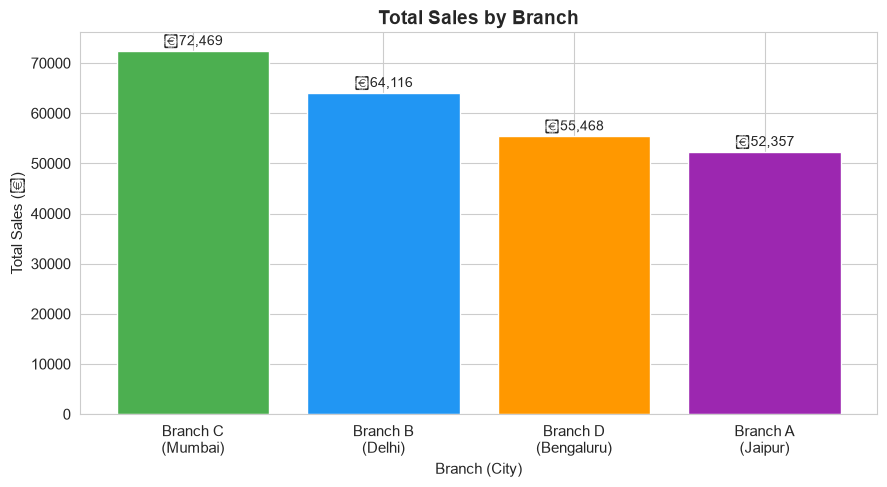

In [22]:
# Chart: Total Sales by Branch
branch_labels = [f'Branch {b}\n({c})' for b, c in branch_analysis.index]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(branch_labels, branch_analysis['Total_Sales'],
              color=['#4CAF50', '#2196F3', '#FF9800', '#9C27B0'], edgecolor='white')

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 500,
            f'₹{height:,.0f}', ha='center', va='bottom', fontsize=10)

ax.set_title('Total Sales by Branch', fontsize=14, fontweight='bold')
ax.set_xlabel('Branch (City)')
ax.set_ylabel('Total Sales (₹)')
plt.tight_layout()
plt.savefig('chart_branch_sales.png', dpi=150, bbox_inches='tight')
plt.show()

### 6D. City Analysis

In [23]:
# City-level analysis
city_analysis = df.groupby('City').agg(
    Total_Sales=('Sales', 'sum'),
    Transaction_Count=('Invoice ID', 'count'),
    Avg_Transaction=('Sales', 'mean')
).round(2).sort_values('Total_Sales', ascending=False)

print('City Analysis:')
city_analysis

City Analysis:


,Total_Sales,Transaction_Count,Avg_Transaction
City,,,
Mumbai,72469.45,143,506.78
Delhi,64116.26,133,482.08
Bengaluru,55468.29,119,466.12
Jaipur,52357.08,105,498.64


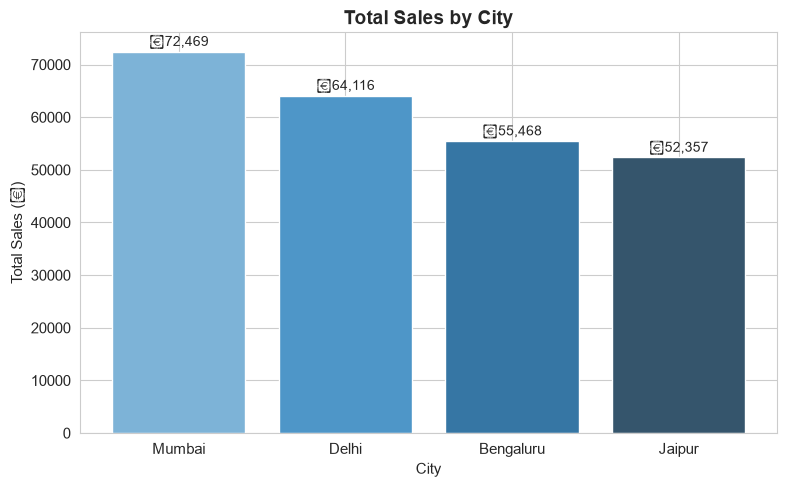

In [24]:
# Chart: Total Sales by City
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(city_analysis.index, city_analysis['Total_Sales'],
              color=sns.color_palette('Blues_d', len(city_analysis)), edgecolor='white')

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 500,
            f'₹{height:,.0f}', ha='center', va='bottom', fontsize=10)

ax.set_title('Total Sales by City', fontsize=14, fontweight='bold')
ax.set_xlabel('City')
ax.set_ylabel('Total Sales (₹)')
plt.tight_layout()
plt.savefig('chart_city_sales.png', dpi=150, bbox_inches='tight')
plt.show()

### 6E. Payment Analysis

In [25]:
# Count transactions and calculate percentage by payment method
payment_analysis = df['Payment'].value_counts().reset_index()
payment_analysis.columns = ['Payment_Method', 'Transaction_Count']
payment_analysis['Percentage'] = (payment_analysis['Transaction_Count'] / len(df) * 100).round(1)

print('Payment Method Analysis:')
payment_analysis

Payment Method Analysis:


,Payment_Method,Transaction_Count,Percentage
0,UPI,127,25.4
1,Net Banking,126,25.2
2,Card,125,25.0
3,Cash,122,24.4


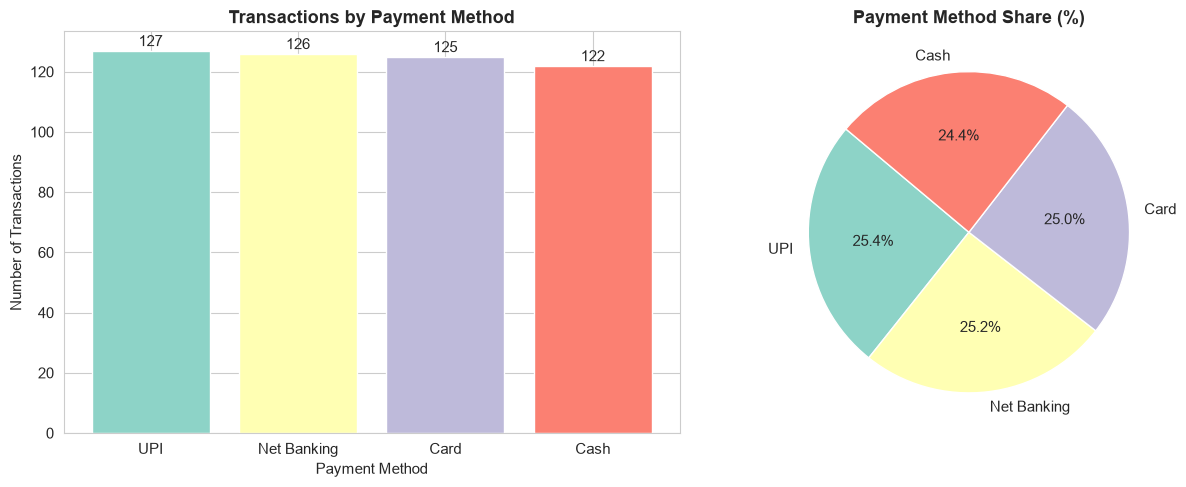

In [26]:
# Chart: Payment Method Distribution (Bar + Pie side by side)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart
colors = sns.color_palette('Set3', len(payment_analysis))
ax1.bar(payment_analysis['Payment_Method'], payment_analysis['Transaction_Count'],
        color=colors, edgecolor='white')
for i, row in payment_analysis.iterrows():
    ax1.text(i, row['Transaction_Count'] + 1.5, str(row['Transaction_Count']),
             ha='center', fontsize=11)
ax1.set_title('Transactions by Payment Method', fontsize=13, fontweight='bold')
ax1.set_xlabel('Payment Method')
ax1.set_ylabel('Number of Transactions')

# Pie chart
ax2.pie(payment_analysis['Transaction_Count'],
        labels=payment_analysis['Payment_Method'],
        autopct='%1.1f%%', colors=colors,
        startangle=140, wedgeprops={'edgecolor': 'white'})
ax2.set_title('Payment Method Share (%)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('chart_payment.png', dpi=150, bbox_inches='tight')
plt.show()

### 6F. Customer Type Analysis

In [27]:
# Compare Member vs Normal customers
customer_analysis = df.groupby('Customer Type').agg(
    Transaction_Count=('Invoice ID', 'count'),
    Total_Sales=('Sales', 'sum'),
    Avg_Sale=('Sales', 'mean'),
    Avg_Quantity=('Quantity', 'mean')
).round(2)

print('Customer Type Analysis:')
customer_analysis

Customer Type Analysis:


,Transaction_Count,Total_Sales,Avg_Sale,Avg_Quantity
Customer Type,,,,
Member,296,143009.30,483.14,5.60
Normal,204,101401.78,497.07,5.44


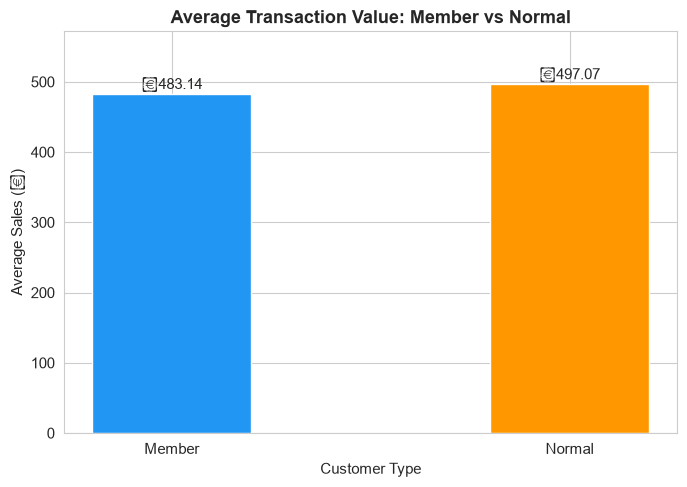

In [28]:
# Chart: Average Transaction Value — Member vs Normal
fig, ax = plt.subplots(figsize=(7, 5))
colors = ['#2196F3', '#FF9800']
bars = ax.bar(customer_analysis.index, customer_analysis['Avg_Sale'], color=colors,
              edgecolor='white', width=0.4)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 2,
            f'₹{height:,.2f}', ha='center', va='bottom', fontsize=11)

ax.set_title('Average Transaction Value: Member vs Normal', fontsize=13, fontweight='bold')
ax.set_xlabel('Customer Type')
ax.set_ylabel('Average Sales (₹)')
ax.set_ylim(0, customer_analysis['Avg_Sale'].max() * 1.15)
plt.tight_layout()
plt.savefig('chart_customer_type.png', dpi=150, bbox_inches='tight')
plt.show()

### 6G. Gender Analysis

In [29]:
# Gender-wise sales comparison
gender_analysis = df.groupby('Gender').agg(
    Transaction_Count=('Invoice ID', 'count'),
    Total_Sales=('Sales', 'sum'),
    Avg_Sale=('Sales', 'mean')
).round(2)

print('Gender Analysis:')
gender_analysis

Gender Analysis:


,Transaction_Count,Total_Sales,Avg_Sale
Gender,,,
Female,255,123954.12,486.09
Male,245,120456.96,491.66


### 6H. Rating Analysis

In [30]:
# Overall average rating
avg_rating = df['Rating'].mean()
print(f'Overall Average Customer Rating: {avg_rating:.2f} / 5.0')

# Rating by Branch
branch_rating = df.groupby('Branch')['Rating'].mean().round(2).sort_values(ascending=False)
print('\nAverage Rating by Branch:')
print(branch_rating)

# Rating by Category
cat_rating = df.groupby('Category')['Rating'].mean().round(2).sort_values(ascending=False)
print('\nAverage Rating by Category:')
print(cat_rating)

Overall Average Customer Rating: 3.99 / 5.0

Average Rating by Branch:
Branch
D    4.09
C    4.05
B    3.98
A    3.84
Name: Rating, dtype: float64

Average Rating by Category:
Category
Bakery           4.24
Snacks           4.11
Dairy            4.03
Vegetables       3.99
Beverages        3.96
Personal Care    3.95
Grocery          3.94
Fruits           3.83
Name: Rating, dtype: float64


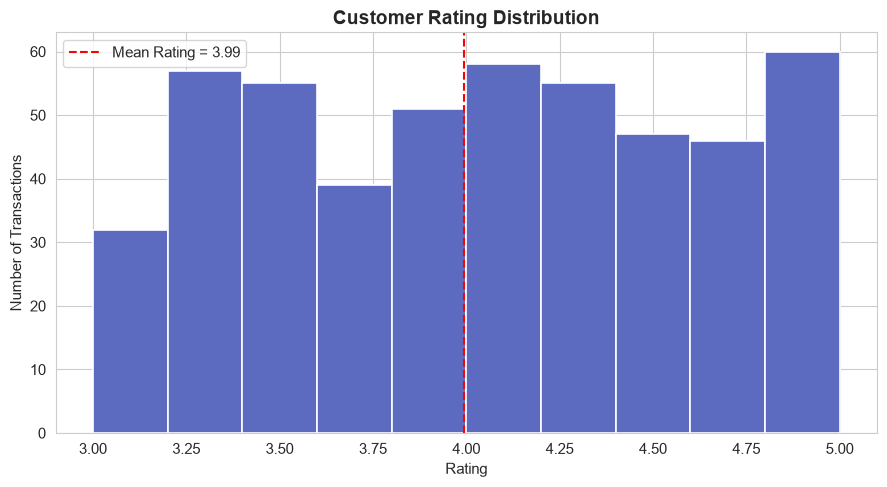

In [31]:
# Chart: Rating Distribution (Histogram)
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(df['Rating'], bins=10, color='#5C6BC0', edgecolor='white', linewidth=1.2)
ax.axvline(avg_rating, color='red', linestyle='--', linewidth=1.5,
           label=f'Mean Rating = {avg_rating:.2f}')
ax.set_title('Customer Rating Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Rating')
ax.set_ylabel('Number of Transactions')
ax.legend()
plt.tight_layout()
plt.savefig('chart_rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 6I. Time Analysis

In [32]:
# Monthly Sales
monthly_sales = df.groupby('Month')['Sales'].sum().reset_index()
monthly_sales['Month'] = monthly_sales['Month'].astype(str)
monthly_sales = monthly_sales.sort_values('Month')

print('Monthly Sales:')
for _, row in monthly_sales.iterrows():
    print(f"  {row['Month']}: ₹{row['Sales']:,.2f}")

Monthly Sales:
  2026-01: ₹43,415.53
  2026-02: ₹30,068.15
  2026-03: ₹37,306.42
  2026-04: ₹52,569.77
  2026-05: ₹42,542.31
  2026-06: ₹35,041.46
  2026-07: ₹3,467.44


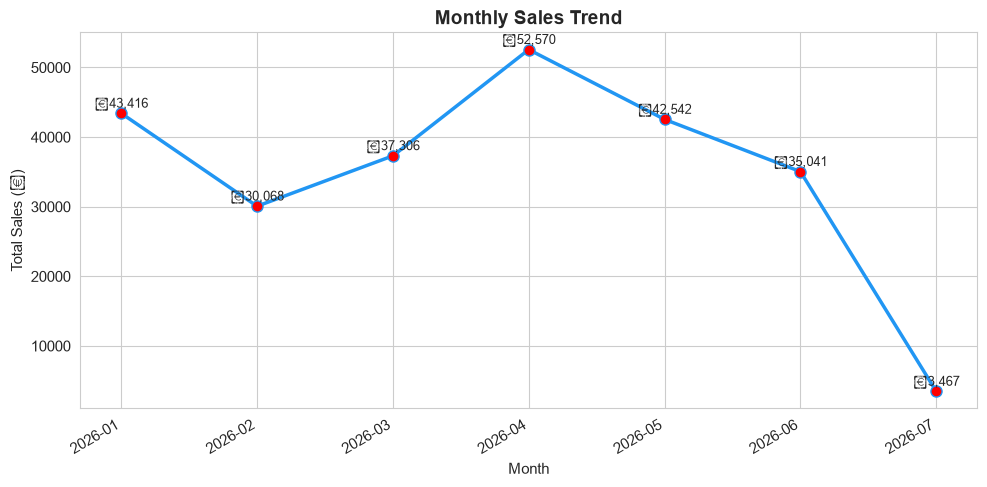

In [33]:
# Chart: Sales Trend by Month (Line Chart)
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(monthly_sales['Month'], monthly_sales['Sales'],
        marker='o', linewidth=2.5, color='#2196F3', markersize=8,
        markerfacecolor='red')

for _, row in monthly_sales.iterrows():
    ax.text(row['Month'], row['Sales'] + 800,
            f"₹{row['Sales']:,.0f}", ha='center', fontsize=9)

ax.set_title('Monthly Sales Trend', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total Sales (₹)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('chart_monthly_sales.png', dpi=150, bbox_inches='tight')
plt.show()

In [34]:
# Day of Week Sales Analysis
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_sales = df.groupby('Day_of_Week')['Sales'].agg(['sum', 'mean', 'count']).reindex(days_order)
dow_sales.columns = ['Total_Sales', 'Avg_Sales', 'Transaction_Count']
dow_sales = dow_sales.round(2)

print('Sales by Day of Week:')
dow_sales

Sales by Day of Week:


,Total_Sales,Avg_Sales,Transaction_Count
Day_of_Week,,,
Monday,42602.44,553.28,77
Tuesday,36293.23,483.91,75
Wednesday,34363.73,464.37,74
Thursday,28576.26,414.15,69
Friday,33026.36,478.64,69
Saturday,32829.15,437.72,75
Sunday,36719.91,601.97,61


---
## 7. Business Questions

All answers are calculated directly from the dataset.

In [35]:
# ---- Q1: Which product generates the highest sales? ----
q1 = product_analysis['Total_Sales'].idxmax()
q1_val = product_analysis.loc[q1, 'Total_Sales']
print(f'Q1. Highest-selling product: {q1} → ₹{q1_val:,.2f}')
print('     Cheese leads all products with ₹27,906 in total sales.')

Q1. Highest-selling product: Cheese → ₹27,906.30
     Cheese leads all products with ₹27,906 in total sales.


In [36]:
# ---- Q2: Which branch performs best? ----
best_branch_idx = branch_analysis['Total_Sales'].idxmax()
best_branch_sales = branch_analysis.loc[best_branch_idx, 'Total_Sales']
print(f'Q2. Best-performing branch: Branch {best_branch_idx[0]} ({best_branch_idx[1]}) → ₹{best_branch_sales:,.2f}')
print('     Branch C in Mumbai generates the highest total revenue.')

Q2. Best-performing branch: Branch C (Mumbai) → ₹72,469.45
     Branch C in Mumbai generates the highest total revenue.


In [37]:
# ---- Q3: Which category sells the most? ----
q3 = category_analysis['Total_Sales'].idxmax()
q3_val = category_analysis.loc[q3, 'Total_Sales']
print(f'Q3. Highest-selling category: {q3} → ₹{q3_val:,.2f}')
print('     Beverages is the top category by total revenue.')

Q3. Highest-selling category: Beverages → ₹56,108.24
     Beverages is the top category by total revenue.


In [38]:
# ---- Q4: Most popular payment method? ----
q4 = payment_analysis.iloc[0]['Payment_Method']
q4_val = payment_analysis.iloc[0]['Transaction_Count']
q4_pct = payment_analysis.iloc[0]['Percentage']
print(f'Q4. Most popular payment method: {q4} → {q4_val} transactions ({q4_pct}%)')
print('     All four payment methods are used almost equally, with UPI being slightly ahead.')

Q4. Most popular payment method: UPI → 127 transactions (25.4%)
     All four payment methods are used almost equally, with UPI being slightly ahead.


In [39]:
# ---- Q5: Do Members spend more than Normal customers? ----
member_avg = customer_analysis.loc['Member', 'Avg_Sale']
normal_avg = customer_analysis.loc['Normal', 'Avg_Sale']
print(f'Q5. Member avg sale: ₹{member_avg:,.2f} | Normal avg sale: ₹{normal_avg:,.2f}')
if normal_avg > member_avg:
    print(f'     Normal customers have a HIGHER average transaction value (₹{normal_avg - member_avg:.2f} more).')
else:
    print(f'     Members have a HIGHER average transaction value (₹{member_avg - normal_avg:.2f} more).')

Q5. Member avg sale: ₹483.14 | Normal avg sale: ₹497.07
     Normal customers have a HIGHER average transaction value (₹13.93 more).


In [40]:
# ---- Q6: What is the average customer rating? ----
print(f'Q6. Average Customer Rating: {df["Rating"].mean():.2f} / 5.0')
print('     Ratings range from 3.0 to 5.0, showing generally positive customer satisfaction.')

Q6. Average Customer Rating: 3.99 / 5.0
     Ratings range from 3.0 to 5.0, showing generally positive customer satisfaction.


In [41]:
# ---- Q7: Which branch has the highest average transaction value? ----
q7_idx = branch_analysis['Avg_Transaction'].idxmax()
q7_val = branch_analysis.loc[q7_idx, 'Avg_Transaction']
print(f'Q7. Highest avg transaction branch: Branch {q7_idx[0]} ({q7_idx[1]}) → ₹{q7_val:,.2f}')

Q7. Highest avg transaction branch: Branch C (Mumbai) → ₹506.78


In [42]:
# ---- Q8: Which category has the highest quantity sold? ----
q8 = category_analysis['Total_Quantity'].idxmax()
q8_val = category_analysis.loc[q8, 'Total_Quantity']
print(f'Q8. Category with highest quantity sold: {q8} → {q8_val} units')

Q8. Category with highest quantity sold: Beverages → 465 units


In [43]:
# ---- Q9: Which customer type generates more total sales? ----
q9 = customer_analysis['Total_Sales'].idxmax()
q9_val = customer_analysis.loc[q9, 'Total_Sales']
print(f'Q9. Customer type with more total sales: {q9} → ₹{q9_val:,.2f}')
print('     Members generate more total revenue due to higher transaction count (296 vs 204).')

Q9. Customer type with more total sales: Member → ₹143,009.30
     Members generate more total revenue due to higher transaction count (296 vs 204).


In [44]:
# ---- Q10: Which city performs best? ----
q10 = city_analysis['Total_Sales'].idxmax()
q10_val = city_analysis.loc[q10, 'Total_Sales']
print(f'Q10. Best-performing city: {q10} → ₹{q10_val:,.2f}')

Q10. Best-performing city: Mumbai → ₹72,469.45


---
## 8. Key Insights

In [45]:
print('=' * 60)
print('         KEY INSIGHTS — SUPERMARKET SALES ANALYSIS')
print('=' * 60)
print(f'Total Transactions         : {len(df)}')
print(f'Total Revenue              : ₹{df["Sales"].sum():,.2f}')
print(f'Average Transaction Value  : ₹{df["Sales"].mean():,.2f}')
print(f'Average Customer Rating    : {df["Rating"].mean():.2f} / 5.0')
print('-' * 60)
print(f'Best-Selling Product       : {product_analysis["Total_Sales"].idxmax()}')
print(f'  Sales                    : ₹{product_analysis["Total_Sales"].max():,.2f}')
print(f'Lowest-Selling Product     : {product_analysis["Total_Sales"].idxmin()}')
print(f'  Sales                    : ₹{product_analysis["Total_Sales"].min():,.2f}')
print('-' * 60)
print(f'Top Category by Sales      : {category_analysis["Total_Sales"].idxmax()}')
print(f'  Sales                    : ₹{category_analysis["Total_Sales"].max():,.2f}')
print(f'Top Category by Quantity   : {category_analysis["Total_Quantity"].idxmax()}')
print(f'  Quantity                 : {category_analysis["Total_Quantity"].max()} units')
print('-' * 60)
best_b = branch_analysis['Total_Sales'].idxmax()
print(f'Best Branch                : Branch {best_b[0]} — {best_b[1]}')
print(f'  Total Sales              : ₹{branch_analysis.loc[best_b, "Total_Sales"]:,.2f}')
print(f'  Avg Transaction          : ₹{branch_analysis.loc[best_b, "Avg_Transaction"]:,.2f}')
print(f'Best City                  : {city_analysis["Total_Sales"].idxmax()}')
print('-' * 60)
print(f'Most-Used Payment Method   : {payment_analysis.iloc[0]["Payment_Method"]} ({payment_analysis.iloc[0]["Transaction_Count"]} txns)')
print(f'Peak Month                 : {monthly_sales.loc[monthly_sales["Sales"].idxmax(), "Month"]} (₹{monthly_sales["Sales"].max():,.2f})')
print(f'Peak Day of Week           : {dow_sales["Avg_Sales"].idxmax()} (avg ₹{dow_sales["Avg_Sales"].max():,.2f}/txn)')
print('-' * 60)
print(f'Member Avg Sale            : ₹{customer_analysis.loc["Member", "Avg_Sale"]:,.2f}')
print(f'Normal Customer Avg Sale   : ₹{customer_analysis.loc["Normal", "Avg_Sale"]:,.2f}')
print(f'Highest-Rated Category     : {cat_rating.idxmax()} (avg {cat_rating.max():.2f})')
print(f'Highest-Rated Branch       : Branch {branch_rating.idxmax()} (avg {branch_rating.max():.2f})')
print('=' * 60)

         KEY INSIGHTS — SUPERMARKET SALES ANALYSIS
Total Transactions         : 500
Total Revenue              : ₹244,411.08
Average Transaction Value  : ₹488.82
Average Customer Rating    : 3.99 / 5.0
------------------------------------------------------------
Best-Selling Product       : Cheese
  Sales                    : ₹27,906.30
Lowest-Selling Product     : Biscuits
  Sales                    : ₹3,908.87
------------------------------------------------------------
Top Category by Sales      : Beverages
  Sales                    : ₹56,108.24
Top Category by Quantity   : Beverages
  Quantity                 : 465 units
------------------------------------------------------------
Best Branch                : Branch C — Mumbai
  Total Sales              : ₹72,469.45
  Avg Transaction          : ₹506.78
Best City                  : Mumbai
------------------------------------------------------------
Most-Used Payment Method   : UPI (127 txns)
Peak Month                 : 2026-04 (₹5

---
## 9. Business Recommendations

Based on the actual analysis results above:

1. **Stock Beverages and Personal Care generously** — These two categories contribute the largest share of revenue (₹56,108 and ₹45,944 respectively). Stockouts in these categories would directly hurt revenue.

2. **Promote Cheese, Coffee, and Shampoo** — These are the three highest-earning products individually. Running combo offers or loyalty discounts on them could increase volumes further.

3. **Investigate and support Jaipur Branch (A)** — Branch A has the lowest total sales (₹52,357) and the lowest average customer rating (3.84). Management should investigate service issues and consider targeted promotions for this location.

4. **Learn from Mumbai Branch (C)** — It leads in both total sales (₹72,469) and average transaction value (₹506.78). Branch C's operational practices should be used as a benchmark for other branches.

5. **Promote Bakery and Snacks with better placement** — These categories receive the highest customer ratings (4.24 and 4.11) but rank last and second-last in total sales. Better shelf placement or bundled deals could increase their contribution.

6. **Support all four payment methods equally** — UPI (25.4%), Net Banking (25.2%), Card (25.0%), and Cash (24.4%) are almost equally used. Ensure all payment systems are always operational to avoid losing any customer segment.

7. **Rethink the membership program benefits** — Normal customers have a slightly higher average transaction value (₹497.07) than Members (₹483.14). While Members contribute more total revenue due to higher count, the membership program may need stronger incentives to increase per-visit spending.

8. **Plan April inventory and staffing carefully** — April 2026 was the peak sales month (₹52,570). Pre-stocking high-demand items and planning for extra staff before April can prevent missed sales.

9. **Run exclusive Sunday deals** — Sunday shows the highest average transaction value per transaction (₹601.97). Limited-time Sunday offers on premium products like Cheese or Coffee could push this even higher.

10. **Monitor Biscuits and Tomato closely** — These have the lowest total sales (₹3,909 and ₹4,325). Consider reducing shelf space or replacing slow movers with higher-margin products.

---
## 10. Final Conclusion

This project performed a complete Exploratory Data Analysis on a supermarket sales dataset of **500 transactions** across **4 branches** in **4 Indian cities** (Mumbai, Delhi, Bengaluru, Jaipur) over the period **January 2026 – July 2026**.

**Major Patterns Found:**
- **Beverages** is the strongest category by both sales (₹56,108) and quantity (465 units).
- **Cheese** is the top individual product with ₹27,906 in revenue.
- **Mumbai (Branch C)** is the best-performing location, contributing ₹72,469 in sales.
- **UPI** is marginally the most popular payment method, but all four methods are nearly equally used.
- **April 2026** was the peak sales month with ₹52,570.
- **Sunday** generates the highest average transaction value (₹601.97).
- **Normal customers** have a slightly higher average transaction value than Members, despite Members having more total transactions.
- **Bakery** receives the highest customer satisfaction rating (4.24) but ranks last in total sales — indicating an opportunity gap.

**How Data Analytics Helped:**  
By applying Python-based data analysis techniques, we converted raw transaction records into actionable business intelligence. Instead of relying on guesswork, the supermarket can now make data-driven decisions about inventory, staffing, marketing, and branch management.

**How Insights Support Business Decisions:**  
- Inventory teams can stock more Beverages and less Biscuits.
- Marketing can plan April campaigns in advance.
- Branch management can study Branch C's success and replicate it elsewhere.
- Customer service teams can focus on improving ratings at Branch A (Jaipur).

This project demonstrates that even a simple descriptive analysis of 500 rows of data can produce clear, practical, and reliable business insights.

---
*End of Analysis*